В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/Colab Notebooks')


In [ ]:
!cp '/content/drive/MyDrive/Colab Notebooks/process_bank_churn.py' .

In [ ]:
import process_bank_churn
#help(process_bank_churn)

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [ ]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/train.csv')

In [ ]:
raw_df[:5]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


**видаляємо непотрібні колонки**

In [ ]:
raw_df = process_bank_churn.drop_columns(raw_df, ['id', 'CustomerId', 'Surname'])


In [ ]:
raw_df[:1]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,678.0,France,Male,29.0,4.0,0.0,3.0,1.0,0.0,180626.36,0.0


**розбиваємо на тренувальні та валідаційні вибірки**

In [ ]:
train_df, val_df = process_bank_churn.split_data(raw_df, target_col='Exited', test_size=0.2)


In [ ]:
print(train_df.shape[0])  # має бути ~80% від raw_df
print(val_df.shape[0])    # має бути ~20%


12000
3000


In [ ]:
y_train = train_df['Exited']
y_val = val_df['Exited']

In [ ]:
y_train, y_val

(7180     0.0
 10393    0.0
 80       0.0
 3365     0.0
 12236    0.0
         ... 
 9493     0.0
 8463     0.0
 8143     0.0
 11512    0.0
 9360     0.0
 Name: Exited, Length: 12000, dtype: float64,
 6490     1.0
 3646     0.0
 5306     0.0
 652      0.0
 2627     0.0
         ... 
 10550    0.0
 8866     1.0
 3244     0.0
 12441    0.0
 3024     0.0
 Name: Exited, Length: 3000, dtype: float64)

In [ ]:
display(train_df)
display(val_df)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0
...,...,...,...,...,...,...,...,...,...,...,...
9493,633.0,France,Female,33.0,4.0,0.00,2.0,0.0,0.0,123537.05,0.0
8463,673.0,France,Female,40.0,1.0,0.00,1.0,1.0,1.0,47832.82,0.0
8143,621.0,France,Male,29.0,8.0,0.00,2.0,1.0,1.0,133535.29,0.0
11512,590.0,Spain,Male,42.0,7.0,0.00,2.0,0.0,0.0,72643.95,0.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6490,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32,1.0
3646,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24,0.0
5306,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05,0.0
652,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76,0.0
2627,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85,0.0
...,...,...,...,...,...,...,...,...,...,...,...
10550,678.0,France,Male,38.0,4.0,0.00,2.0,1.0,0.0,133535.29,0.0
8866,753.0,France,Male,54.0,6.0,0.00,1.0,1.0,0.0,177065.24,1.0
3244,678.0,Spain,Male,32.0,5.0,0.00,2.0,1.0,0.0,176712.59,0.0
12441,724.0,Spain,Male,33.0,5.0,138162.41,1.0,1.0,0.0,105720.09,0.0


**визначаємо категоріальні та числові колонки**

In [ ]:
numeric_cols, categorical_cols = process_bank_churn.get_numeric_and_categorical_columns(raw_df)


In [ ]:
numeric_cols, categorical_cols

(['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary',
  'Exited'],
 ['Geography', 'Gender'])

Імпутації не буде, оскільки немає значень нульових.\
**Масштабувати будемо колонки CreditScore, Age, Tenure, Balance, NumofProducts, EstimatedSalary**
HasCrCard та Is ActiveMember це бінарні колонки, тому їх не масштабуємо.

In [ ]:
train_df[:1]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0


In [ ]:
selected_df = process_bank_churn.select_columns(train_df, include_cols=[
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary'
])


In [ ]:
scale_cols = selected_df.columns.tolist()
scaler = process_bank_churn.fit_scaler(df=selected_df, scale_cols=scale_cols)


In [ ]:
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
selected_df = selected_df[scale_cols]  # впорядковуємо колонки
train_scaled = process_bank_churn.transform_scaler(selected_df, scaler, scale_cols=scale_cols)


In [ ]:
train_scaled[:2]

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.569450
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.603803


In [ ]:
val_selected = process_bank_churn.select_columns(val_df, include_cols=scale_cols)
val_selected = val_selected[scale_cols]  # впорядкування

# Масштабування через уже навчений scaler
val_scaled = process_bank_churn.transform_scaler(val_selected, scaler, scale_cols=scale_cols)

In [ ]:
val_selected

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
6490,714.0,46.0,1.0,115764.32,4.0,72945.32
3646,593.0,41.0,5.0,0.00,2.0,38196.24
5306,731.0,38.0,2.0,0.00,2.0,116971.05
652,673.0,43.0,4.0,155739.76,1.0,111622.76
2627,678.0,30.0,4.0,0.00,2.0,143681.85
...,...,...,...,...,...,...
10550,678.0,38.0,4.0,0.00,2.0,133535.29
8866,753.0,54.0,6.0,0.00,1.0,177065.24
3244,678.0,32.0,5.0,0.00,2.0,176712.59
12441,724.0,33.0,5.0,138162.41,1.0,105720.09


In [ ]:
val_scaled

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,-0.988144
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,-1.750392
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,-0.022404
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,-0.139723
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.563519
...,...,...,...,...,...,...
10550,0.264887,0.038348,-0.368848,-0.717950,0.769304,0.340946
8866,1.301774,2.004409,0.350096,-0.717950,-1.108193,1.295810
3244,0.264887,-0.698924,-0.009376,-0.717950,0.769304,1.288074
12441,0.900844,-0.576046,-0.009376,1.588442,-1.108193,-0.269203


**Тепер кодуємо категоріальні колонки**\
Використаємо Onehot encoder та кодування для бінарної колонки

In [ ]:
train_selected_binary = process_bank_churn.select_columns(train_df, include_cols=['Gender'])

In [ ]:
train_selected_binary

,Gender
7180,Male
10393,Female
80,Male
3365,Male
12236,Male
...,...
9493,Female
8463,Female
8143,Male
11512,Male


In [ ]:
valid_selected_binary = process_bank_churn.select_columns(val_df, include_cols=['Gender'])

In [ ]:
valid_selected_binary

,Gender
6490,Male
3646,Male
5306,Female
652,Female
2627,Female
...,...
10550,Male
8866,Male
3244,Male
12441,Male


In [ ]:
train_binary_encoded = process_bank_churn.encode_binary_column(train_selected_binary, 'Gender', true_value = 'Male')
valid_binary_encoded = process_bank_churn.encode_binary_column(valid_selected_binary, 'Gender', true_value = 'Male')

In [ ]:
train_binary_encoded, valid_binary_encoded

(       Gender
 7180        1
 10393       0
 80          1
 3365        1
 12236       1
 ...       ...
 9493        0
 8463        0
 8143        1
 11512       1
 9360        0
 
 [12000 rows x 1 columns],
        Gender
 6490        1
 3646        1
 5306        0
 652         0
 2627        0
 ...       ...
 10550       1
 8866        1
 3244        1
 12441       1
 3024        1
 
 [3000 rows x 1 columns])

In [ ]:
print(train_df.columns.tolist())


['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
geo_encoder = process_bank_churn.fit_onehot_encoder(train_df, col='Geography')


In [ ]:
train_encoded = pd.DataFrame(
    geo_encoder.transform(train_df[['Geography']]),
    columns=geo_encoder.get_feature_names_out(['Geography']),
    index=train_df.index
)

val_encoded = pd.DataFrame(
    geo_encoder.transform(val_df[['Geography']]),
    columns=geo_encoder.get_feature_names_out(['Geography']),
    index=val_df.index
)


In [ ]:
train_encoded[:1]

,Geography_France,Geography_Germany,Geography_Spain
7180,1.0,0.0,0.0


**видалимо колонку гендер з закодованих категоріальних датафреймів тестового та валідаційного та обʼєднаємо все у один числовий датафрейм**

In [ ]:
#train_encoded, val_encoded = process_bank_churn.drop_columns(train_encoded, ['Gender']), process_bank_churn.drop_columns(val_encoded, ['Gender'])

In [ ]:
train_final_df = pd.concat([
    train_scaled.reset_index(drop=True),
    train_binary_encoded[['Gender']].reset_index(drop=True),
    train_encoded.reset_index(drop=True),
    train_df[['HasCrCard', 'IsActiveMember']].reset_index(drop=True)
], axis=1)

val_final_df = pd.concat([
    val_scaled.reset_index(drop=True),
    valid_binary_encoded[['Gender']].reset_index(drop=True),
    val_encoded.reset_index(drop=True),
    val_df[['HasCrCard', 'IsActiveMember']].reset_index(drop=True)
], axis=1)


In [ ]:
display(train_final_df)
display(val_final_df)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Gender,Geography_France,Geography_Germany,Geography_Spain,HasCrCard,IsActiveMember
0,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.569450,1,1.0,0.0,0.0,1.0,1.0
1,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.603803,0,1.0,0.0,0.0,1.0,0.0
2,0.638166,-0.330288,0.350096,1.223831,0.769304,1.238026,1,0.0,1.0,0.0,1.0,0.0
3,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.457116,1,0.0,0.0,1.0,0.0,1.0
4,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.670629,1,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-0.357246,-0.576046,-0.368848,-0.717950,0.769304,0.121626,0,1.0,0.0,0.0,0.0,0.0
11996,0.195761,0.284106,-1.447264,-0.717950,-1.108193,-1.539006,0,1.0,0.0,0.0,1.0,1.0
11997,-0.523147,-1.067561,1.069040,-0.717950,0.769304,0.340946,1,1.0,0.0,0.0,1.0,1.0
11998,-0.951727,0.529864,0.709568,-0.717950,0.769304,-0.994754,1,0.0,0.0,1.0,0.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Gender,Geography_France,Geography_Germany,Geography_Spain,HasCrCard,IsActiveMember
0,0.762592,1.021379,-1.447264,1.214543,4.524299,-0.988144,1,0.0,1.0,0.0,1.0,1.0
1,-0.910252,0.406985,-0.009376,-0.717950,0.769304,-1.750392,1,1.0,0.0,0.0,1.0,1.0
2,0.997620,0.038348,-1.087792,-0.717950,0.769304,-0.022404,0,1.0,0.0,0.0,0.0,1.0
3,0.195761,0.652742,-0.368848,1.881867,-1.108193,-0.139723,0,1.0,0.0,0.0,0.0,1.0
4,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.563519,0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.264887,0.038348,-0.368848,-0.717950,0.769304,0.340946,1,1.0,0.0,0.0,1.0,0.0
2996,1.301774,2.004409,0.350096,-0.717950,-1.108193,1.295810,1,1.0,0.0,0.0,1.0,0.0
2997,0.264887,-0.698924,-0.009376,-0.717950,0.769304,1.288074,1,0.0,0.0,1.0,1.0,0.0
2998,0.900844,-0.576046,-0.009376,1.588442,-1.108193,-0.269203,1,0.0,0.0,1.0,1.0,0.0


In [ ]:
print(train_final_df.shape[0])  # має бути ~80% від raw_df
print(val_final_df.shape[0])

12000
3000


**Тренування моделі**

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
y_train, y_val

(7180     0.0
 10393    0.0
 80       0.0
 3365     0.0
 12236    0.0
         ... 
 9493     0.0
 8463     0.0
 8143     0.0
 11512    0.0
 9360     0.0
 Name: Exited, Length: 12000, dtype: float64,
 6490     1.0
 3646     0.0
 5306     0.0
 652      0.0
 2627     0.0
         ... 
 10550    0.0
 8866     1.0
 3244     0.0
 12441    0.0
 3024     0.0
 Name: Exited, Length: 3000, dtype: float64)

In [ ]:
model.fit(train_final_df, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
train_probs = model.predict_proba(train_final_df)[:, 1]
val_probs = model.predict_proba(val_final_df)[:, 1]


In [ ]:
test_df = pd.read_csv('drive/MyDrive/Colab Notebooks/test.csv')

In [ ]:
test_df[:1]

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86


In [ ]:
test_final_df = process_bank_churn.process_new_data(
    new_df=test_df.iloc[:, 3:],  # пропускаємо перші три колонки
    scaler=scaler,
    scale_cols=scale_cols,
    encoders={'Geography': geo_encoder},
    binary_columns={'Gender': 'Female'},
    ordered_columns=None
)

In [ ]:
train_final_df[:1]

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Gender,Geography_France,Geography_Germany,Geography_Spain,HasCrCard,IsActiveMember
0,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.56945,1,1.0,0.0,0.0,1.0,1.0


In [ ]:
test_final_df[:1]

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-1.034678,0,-0.944682,-1.087792,1.720173,-1.108193,1.0,1.0,0.875226,0.0,1.0,0.0


In [ ]:
test_final_df = test_final_df[train_final_df.columns] # впорядковуємо колонки

In [ ]:
test_probs = model.predict_proba(test_final_df)[:, 1]

In [ ]:
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"ROC AUC на тренувальних: {train_auc:.4f}")
print(f"ROC AUC на валідаційних: {val_auc:.4f}")


ROC AUC на тренувальних: 1.0000
ROC AUC на валідаційних: 0.7747


**Висновок**\
як бачимо зі значень метрики ROC AUC модель перенавчилась

In [ ]:
model.tree_.max_depth

26

**побудуємо дерево глибиною 2 вузли**

In [ ]:
model_2 = DecisionTreeClassifier(max_depth= 2 , random_state=42)
model_2.fit(train_final_df, y_train)


DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
train_probs_2 = model_2.predict_proba(train_final_df)[:, 1]
val_probs_2 = model_2.predict_proba(val_final_df)[:, 1]

In [ ]:
train_2_auc = roc_auc_score(y_train, train_probs_2)
val_2_auc = roc_auc_score(y_val, val_probs_2)

print(f"ROC AUC на тренувальних: {train_2_auc:.4f}")
print(f"ROC AUC на валідаційних: {val_2_auc:.4f}")

ROC AUC на тренувальних: 0.8429
ROC AUC на валідаційних: 0.8465


In [ ]:
importance_df = pd.DataFrame({
    'feature': train_final_df.columns,
    'importance': model.feature_importances_
})
importance_df = importance_df.sort_values(by='importance', ascending=False)


In [ ]:
print(importance_df.head(10))


              feature  importance
1                 Age    0.357436
4       NumOfProducts    0.168379
5     EstimatedSalary    0.125309
0         CreditScore    0.121843
3             Balance    0.078811
2              Tenure    0.054384
11     IsActiveMember    0.033404
6              Gender    0.017746
8   Geography_Germany    0.015110
10          HasCrCard    0.011364


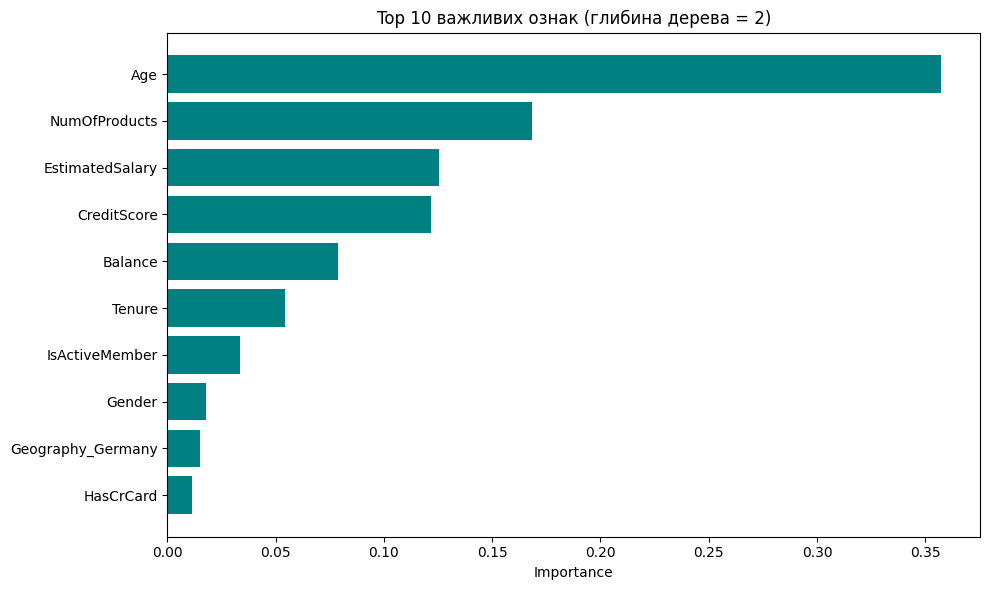

In [ ]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 важливих ознак (глибина дерева = 2)')
plt.tight_layout()
plt.show()


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [ ]:
model_3 = DecisionTreeClassifier(max_leaf_nodes= 77, random_state=42)
model_3.fit(train_final_df, y_train)

train_probs_3 = model_3.predict_proba(train_final_df)[:, 1]
val_probs_3 = model_3.predict_proba(val_final_df)[:, 1]

train_3_auc = roc_auc_score(y_train, train_probs_3)
val_3_auc = roc_auc_score(y_val, val_probs_3)

print(f"ROC AUC на тренувальних: {train_3_auc:.4f}")
print(f"ROC AUC на валідаційних: {val_3_auc:.4f}")

ROC AUC на тренувальних: 0.9342
ROC AUC на валідаційних: 0.9187


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [ ]:
train_aucs = []
val_aucs = []
depths = range(1, 21)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(train_final_df, y_train)

    train_probs = model.predict_proba(train_final_df)[:, 1]
    val_probs = model.predict_proba(val_final_df)[:, 1]

    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)


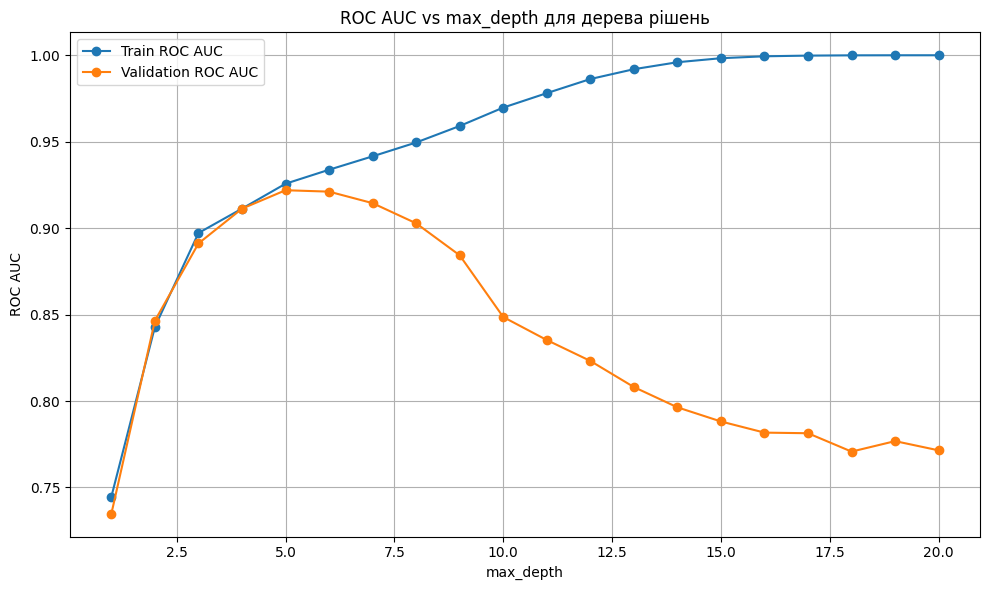

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_aucs, label='Train ROC AUC', marker='o')
plt.plot(depths, val_aucs, label='Validation ROC AUC', marker='o')
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('ROC AUC vs max_depth для дерева рішень')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**як видно з графіка найкраща глибина дерева це приблизно 6**

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [ ]:
model_test_data = DecisionTreeClassifier(max_depth= 6 , random_state=42)
model_test_data.fit(train_final_df, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [ ]:
test_probs = model_test_data.predict_proba(test_final_df)[:, 1]

In [ ]:
test_probs

array([0.17120623, 0.03942181, 0.01578947, ..., 0.01677149, 0.04022526,
       0.28105906])

In [ ]:
# Формуємо фінальний submission
sample_submission = pd.read_csv('drive/MyDrive/Colab Notebooks/sample_submission.csv')
sample_submission['Exited'] = test_probs
sample_submission.to_csv('submission_log_reg.csv', index=False)


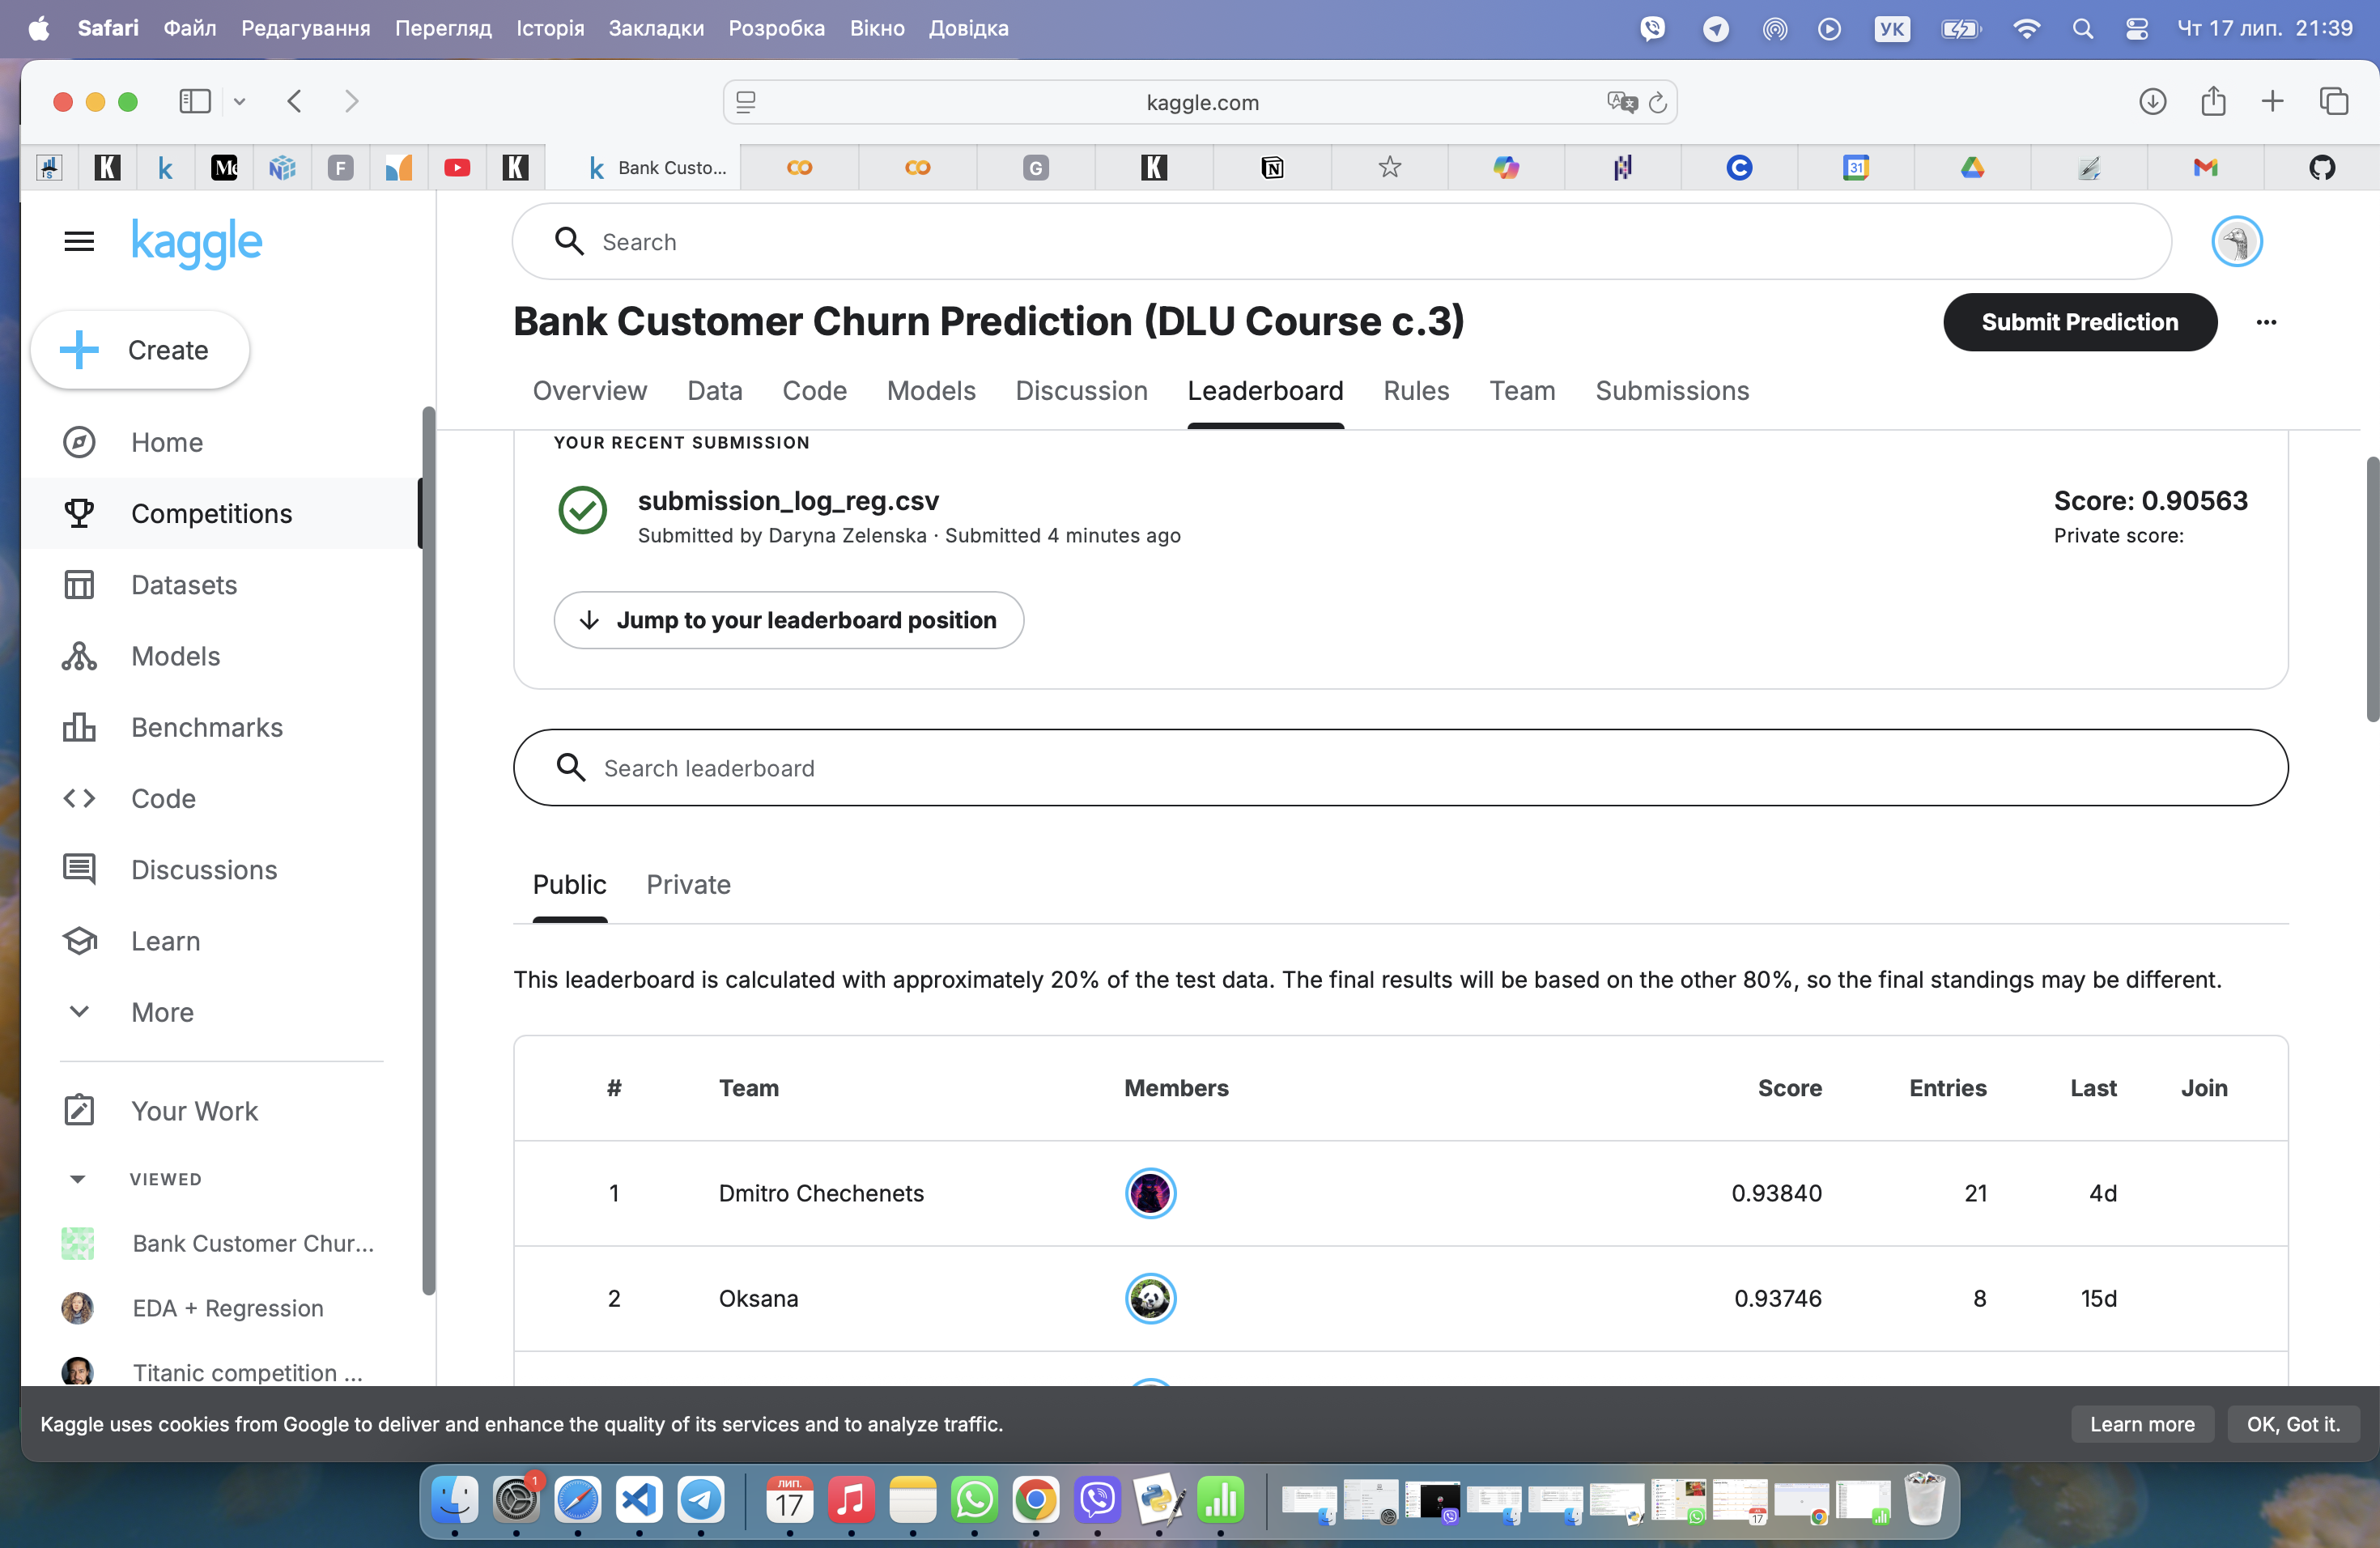